In [1]:


try:
    import secmlt
except ImportError:
   %pip install secml-torch[foolbox,adv_lib]


In [2]:
import torch
import torchvision.datasets
import torchvision.transforms as transforms
from robustbench.utils import load_model
from secmlt.metrics.classification import Accuracy, AttackSuccessRate
from secmlt.models.pytorch.base_pytorch_nn import BasePytorchClassifier
from torch.utils.data import DataLoader, Subset

In [3]:
net = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)

#setting the device
device = "cuda" if torch.cuda.is_available() else "cpu"
net.to(device)
net.eval()

transform = transforms.Compose([transforms.ToTensor()])

#loading the CIFAR10 Dataset
dataset_path = "data/datasets/"
num_samples = 5
test_dataset = torchvision.datasets.CIFAR10(
    transform=transform,
    train=False,
    root=dataset_path,
    download=True,
)
test_dataset = Subset(test_dataset, list(range(num_samples)))
test_data_loader = DataLoader(test_dataset, batch_size=5, shuffle=False)

cifar10_labels = {
    0: "airplane", 1: "automobile", 2: "bird", 3: "cat", 4: "deer",
    5: "dog", 6: "frog", 7: "horse", 8: "ship", 9: "truck"
}

# Wrap model
model = BasePytorchClassifier(net, preprocessing=transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)))

# Test accuracy on original data
accuracy = Accuracy()(model, test_data_loader)
print("Testing the pretrained native model - Accuracy:", accuracy.item())

Using cache found in /home/abarsky/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Testing the pretrained native model - Accuracy: 1.0


In [4]:
from secmlt.adv.backends import Backends
from secmlt.adv.evasion.perturbation_models import LpPerturbationModels
from secmlt.adv.evasion.pgd import PGD

# Create and run untargeted attack
epsilon = 0.1
num_steps = 5
step_size = 0.02
perturbation_model = LpPerturbationModels.LINF
y_target = None
native_attack = PGD(
    perturbation_model=perturbation_model,
    epsilon=epsilon,
    num_steps=num_steps,
    step_size=step_size,
    random_start=False,
    y_target=y_target,
    backend=Backends.NATIVE,
)
native_adv_ds_u = native_attack(model, test_data_loader)

# Test accuracy on adversarial examples
n_robust_accuracy = Accuracy()(model, native_adv_ds_u)
print("Robust Accuracy (PGD Native, Untargeted): ", n_robust_accuracy.item())



# Create and run targeted attack
epsilon = 0.2
num_steps = 10
step_size = 0.02
perturbation_model = LpPerturbationModels.LINF
y_target = 5
native_attack = PGD(
    perturbation_model=perturbation_model,
    epsilon=epsilon,
    num_steps=num_steps,
    step_size=step_size,
    random_start=False,
    y_target=y_target,
    backend=Backends.NATIVE,
)
native_adv_ds_t = native_attack(model, test_data_loader)

# Test attack success rate on adversarial examples
n_robust_accuracy = AttackSuccessRate(y_target=y_target)(model, native_adv_ds_t)
print("ASR (PGD Native, Targeted): ", n_robust_accuracy.item())



Robust Accuracy (PGD Native, Untargeted):  0.0
ASR (PGD Native, Targeted):  1.0


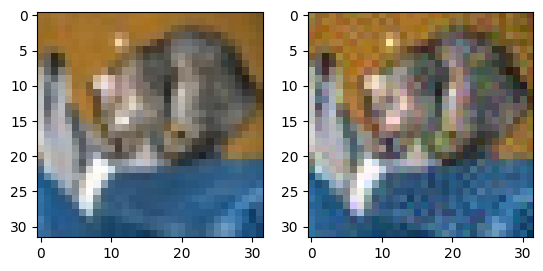

In [5]:
test_x, test_y = next(iter(test_data_loader))
adv_x, adv_y = next(iter(native_adv_ds_u))


import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
adv_img = to_pil_image(adv_x[0])
test_img = to_pil_image(test_x[0])

fig, axes = plt.subplots(1,2)
axes[0].imshow(test_img)
axes[1].imshow(adv_img)
plt.show()


In [194]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage, Resize

perturbed_datasets = {"Targeted":native_adv_ds_t,
                     "Untargeted":native_adv_ds_u,}
# results = {}

# # Selects the last sample from the original dataset and each adversarial dataset
# # Stores the original/adversarial tensors and their predicted class labels
# for name, adv_ds in perturbed_datasets.items():
#   xs_orig, ys_true = next(iter(test_data_loader))
#   x_orig, y_true = xs_orig[-1].unsqueeze(0), ys_true[-1]
#   orig_label = class_names[model.predict(x_orig).item()]

#   xs_adv, ys_true = next(iter(adv_ds))
#   x_adv, y_true = xs_adv[-1].unsqueeze(0)    , ys_true[-1]
#   adv_label = class_names[model.predict(x_adv).item()]

#   results[name] = {
#           "orig_tensor": x_orig,
#           "adv_tensor":  x_adv,
#           "orig_label":  orig_label,
#           "adv_label":   adv_label
#       }

def to_numpy_rescaled(img_tensor, scale=8):
    to_pil = ToPILImage()
    img_pil = to_pil(img_tensor.cpu().detach())
    img_pil = Resize((img_pil.size[1]*scale, img_pil.size[0]*scale))(img_pil)
    return np.array(img_pil)


def plot_adversarial_example(start_tensor, adv_tensor,
                             orig_label=None, delta_label=None, adv_label=None,
                             attack_name=None,
                             figsize=(12, 5), upscale_factor=8):
    """
    Plot original image, amplified perturbation, and adversarial image side by side,
    with the attack name as a figure title.
    Images are upscaled for clarity.
    """
    # Get tensors in shape [C, H, W]
    if start_tensor.ndim == 4:
        start_tensor = start_tensor[0]
    if adv_tensor.ndim == 4:
        adv_tensor = adv_tensor[0]

    # Convert and upscale
    orig_img = to_numpy_rescaled(start_tensor, upscale_factor)
    adv_img = to_numpy_rescaled(adv_tensor, upscale_factor)

    # Compute and upscale perturbation
    perturb = (start_tensor - adv_tensor).cpu().detach().numpy()
    perturb -= perturb.min()
    if perturb.max() > 0:
        perturb /= perturb.max()
    perturb = np.transpose(perturb, (1, 2, 0))  # C×H×W → H×W×C
    perturb = np.array(perturb)

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.text(0.335, 0.4, "+", fontsize=24, ha='center', va='center')
    fig.text(0.665, 0.4, "=", fontsize=24, ha='center', va='center')
    if attack_name:
        fig.suptitle(attack_name, fontsize=14)

    axes[0].imshow(orig_img)
    axes[0].set_title(orig_label or "Original")
    axes[0].axis('off')

    axes[1].imshow(perturb)
    axes[1].set_title(delta_label or "ε x perturbation")
    axes[1].axis('off')

    axes[2].imshow(adv_img)
    axes[2].set_title(adv_label or "Adversarial")
    axes[2].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

# #Plot all at the end
# for name, data in results.items():
#     plot_adversarial_example(
#         start_tensor=data["orig_tensor"],
#         adv_tensor=data["adv_tensor"],
#         orig_label=f"{data['orig_label']} (clean)",
#         adv_label=f"{data['adv_label']} (adv)",
#         attack_name=f"{name} Attack"
#     )


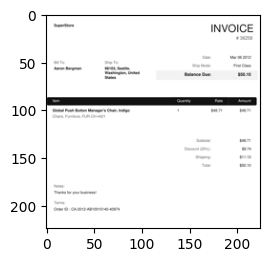

In [454]:
# load my calibratoin image:


import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import rcParams

from os import path
from IPython.display import display
import sys, pdb

import viz

viz.calib['plot_dpi'] = 80.7

# natural example image:
nimage = Image.open('/home/abarsky/data/calibration/magpie.jpg').convert('RGB')

# document example image:
from pdf2image import convert_from_path
# from https://github.com/femstac/Sample-Pdf-invoices/blob/main/1000%2B%20PDF_Invoice_Folder.zip
doc_images = convert_from_path('/home/abarsky/data/sample_invoice_pdfs/invoice_Aaron Bergman_36258.pdf')
dimage = doc_images[0]
dimage.save('/home/abarsky/data/calibration/sample_invoice.png')

# resize to imagenet scale:
# but without warping
nimage_crop = nimage.crop((0,100,448,548))
nimage_ds = nimage_crop.resize((224,224))

dimage_crop = dimage.crop((75,0,224*7 + 75,224*7))
dimage_ds = dimage_crop.resize((224*3,224*3))
dimage_dss = dimage_crop.resize((224,224))

# source_img = nimage_crop
source_img = dimage_dss

from viz import normalise, rshow, get_ppd
from pyramid import gaussian_blur, laplacian_pyramid, inject_noise, bandlimited_noise, get_gaussian_kernel
from oklab import srgb_to_oklab, oklab_to_srgb
from csf import lum_csf, rg_csf, yb_csf    


source_arr = np.asarray(source_img)
# darr = np.asarray(dimage)
rshow(source_arr)

calib_class = 18  # magpie


/home/abarsky/miniconda3/envs/adv/lib/python3.12/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


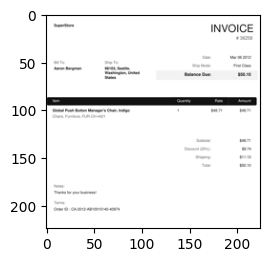

Prediction: 922 (menu; incorrect)


In [520]:
### load imagenet model to attack calibration image:

model_choice = 'vit'

if model_choice == 'resnet':
    from torchvision.models import ResNet50_Weights
    weights = ResNet50_Weights.DEFAULT
    net = torch.hub.load("pytorch/vision", "resnet50", weights=weights)
    class_names = weights.meta['categories']


elif model_choice == 'vit':
    from torchvision.models import vit_b_32, ViT_B_32_Weights
    weights = ViT_B_32_Weights.DEFAULT
    net = vit_b_32(weights)
    class_names = weights.meta['categories']

elif model_choice == 'donut':
    raise NotImplementedError # too weird
    
    from transformers import DonutProcessor, VisionEncoderDecoderModel
    from datasets import load_dataset_builder
    # class_names = load_dataset_builder("rvl_cdip").info.features["label"].names
    class_names = ["letter", "form", "email", "handwritten", "advertisement", "scientific_report", "scientific_publication", "specification", "file_folder", "news_article", "budget", "invoice", "presentation", "questionnaire", "resume", "memo"]
    
    processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base-finetuned-rvlcdip")
    net = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base-finetuned-rvlcdip")

else:
    raise ValueError(f"what is {model_choice}?")

net.to(device)
net.eval()

# ImageNet preprocessing (224x224, normalized with ImageNet stats)
transform = transforms.Compose([
    # transforms.Resize((224, 224)),  # Ensure it's 224x224
    transforms.ToTensor(),

])


class SingleImageDataset(torch.utils.data.Dataset):
    def __init__(self, image, label, transform=None):
        self.image = image
        self.label = label
        self.transform = transform
    
    def __len__(self):
        return 1
    
    def __getitem__(self, idx):
        img = self.image
        if self.transform:
            img = self.transform(img)
        return img, self.label

test_dataset = SingleImageDataset(source_img, calib_class, transform=transform)
test_data_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# for unnormalising:
orig_arr = np.asarray(nimage_ds) # uint8
orig_mean = orig_arr.mean((0,1)) # [96.93024554, 94.23624841, 80.32198661]
orig_std = orig_arr.std((0,1)) # [45.53966191, 40.64174682, 38.4534867 ]


# test model:

batch_x, batch_y = next(iter(test_data_loader))
out_logit = net(batch_x.to(device))
out_idx = out_logit.argmax(1)
out_class = class_names[out_idx.item()]

check_str = 'correct' if out_idx.item() == calib_class else 'incorrect'

# sanity check to display image:
timg = (batch_x.squeeze().permute([1,2,0]))
rshow(timg)

print(f'Prediction: {out_idx.item()} ({class_names[out_idx.item()]}; {check_str})')


# Use ImageNet normalization instead of CIFAR-10 normalization
model = BasePytorchClassifier(
    net, 
    preprocessing = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )    
)

def unnormalize(tensor, orig_mean=orig_mean, orig_std=orig_std, 
                norm_mean=[0.485, 0.456, 0.406], 
                norm_std=[0.229, 0.224, 0.225]):
    """
    Reverse ImageNet normalization and apply original image statistics.
    
    Args:
        tensor: Normalized tensor (C, H, W) or (B, C, H, W)
        orig_mean: Original per-channel means [R, G, B]
        orig_std: Original per-channel stds [R, G, B]
        norm_mean: Mean used for normalization (default: ImageNet)
        norm_std: Std used for normalization (default: ImageNet)
    
    Returns:
        Tensor with original statistics restored
    """
    # Convert to tensors and reshape for broadcasting
    norm_mean = torch.tensor(norm_mean).view(-1, 1, 1)
    norm_std = torch.tensor(norm_std).view(-1, 1, 1)
    orig_mean = torch.tensor(orig_mean).view(-1, 1, 1)
    orig_std = torch.tensor(orig_std).view(-1, 1, 1)
    
    # Move to same device as input
    device = tensor.device
    norm_mean, norm_std = norm_mean.to(device), norm_std.to(device)
    orig_mean, orig_std = orig_mean.to(device), orig_std.to(device)
    
    # Reverse: first undo normalization to get [0,1], then apply original stats
    tensor = tensor * norm_std + norm_mean  # Back to [0, 1] range
    tensor = tensor * orig_std + orig_mean   # Apply original statistics
    
    return tensor

Robust Accuracy (PGD Native, Untargeted):  0.0
ASR (PGD Native, Targeted):  1.0


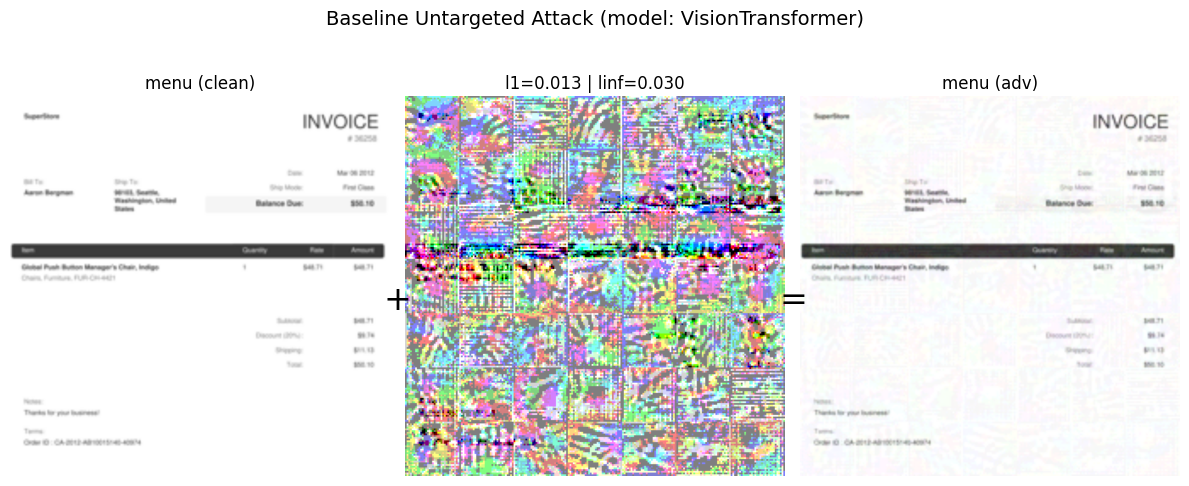

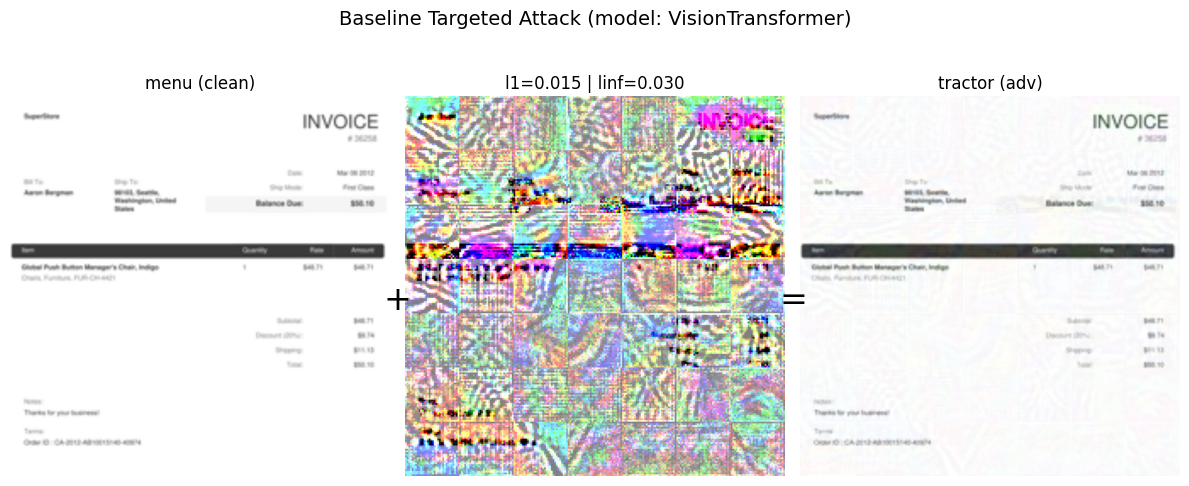

In [521]:
from secmlt.adv.backends import Backends
from secmlt.adv.evasion.perturbation_models import LpPerturbationModels
from secmlt.adv.evasion.pgd import PGD

# Create and run untargeted attack
epsilon = 0.03
num_steps = 5
step_size = 0.02
perturbation_model = LpPerturbationModels.LINF
y_target = None
native_attack = PGD(
    perturbation_model=perturbation_model,
    epsilon=epsilon,
    num_steps=num_steps,
    step_size=step_size,
    random_start=False,
    y_target=y_target,
    backend=Backends.NATIVE,
)
native_adv_ds_u = native_attack(model, test_data_loader)

# Test accuracy on adversarial examples
n_robust_accuracy = Accuracy()(model, native_adv_ds_u)
print("Robust Accuracy (PGD Native, Untargeted): ", n_robust_accuracy.item())



# Create and run targeted attack
num_steps = 50
step_size = epsilon/10
perturbation_model = LpPerturbationModels.LINF
y_target = 866 # tractor
native_attack = PGD(
    perturbation_model=perturbation_model,
    epsilon=epsilon,
    num_steps=num_steps,
    step_size=step_size,
    random_start=False,
    y_target=y_target,
    backend=Backends.NATIVE,
)
native_adv_ds_t = native_attack(model, test_data_loader)

# Test attack success rate on adversarial examples
n_robust_accuracy = AttackSuccessRate(y_target=y_target)(model, native_adv_ds_t)
print("ASR (PGD Native, Targeted): ", n_robust_accuracy.item())

for attack_loader, name in zip([native_adv_ds_u, native_adv_ds_t], ['Untargeted', 'Targeted']):
    
    orig_x, adv_x = next(iter(test_data_loader))[0], next(iter(attack_loader))[0]

    delta = (adv_x - orig_x)
    delta_l1 = delta.abs().mean().item()
    delta_linf = delta.abs().max().item()

    darr = delta[0].permute([1,2,0]).detach().cpu().numpy() # as RGB numpy array wrt [0,1] float image
    
    adv_logit = model(adv_x.to(device))
    adv_idx = adv_logit.argmax(1)
    adv_class = class_names[adv_idx.item()]
    
    plot_adversarial_example(orig_x[0], adv_x[0],                
            orig_label=f"{out_class} (clean)",
            adv_label=f"{adv_class} (adv)",
                             delta_label=f"l1={delta_l1:.3f} | linf={delta_linf:.3f}", 
            attack_name=f"Baseline {name} Attack (model: {str(model.model.__class__).split('.')[-1].split('\'')[0]})")

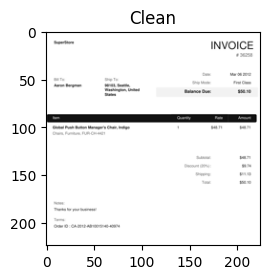

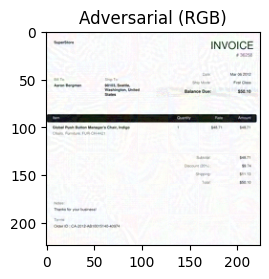

In [522]:
tshow(orig_x[0], title='Clean')
tshow(adv_x[0], title='Adversarial (RGB)')

Pixels per degree: 36.44


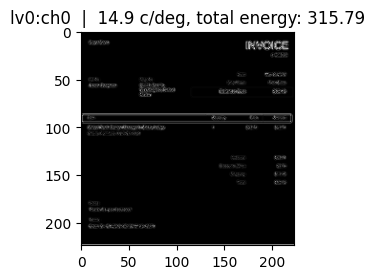

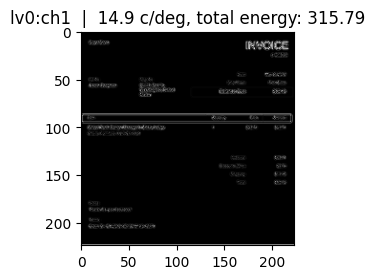

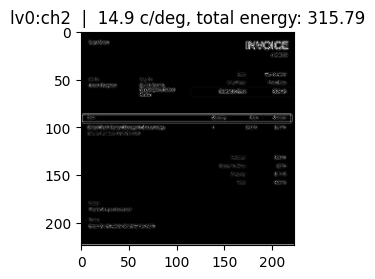

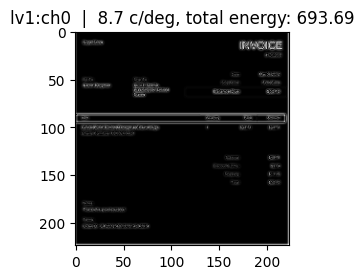

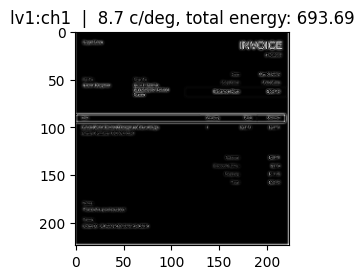

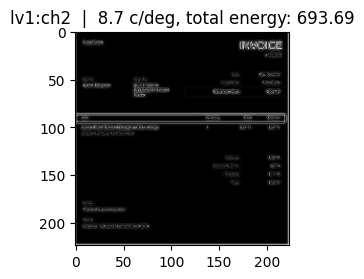

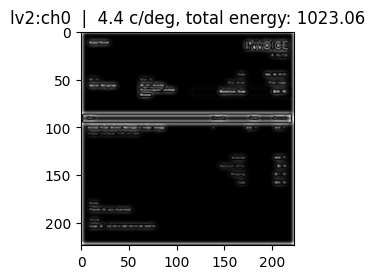

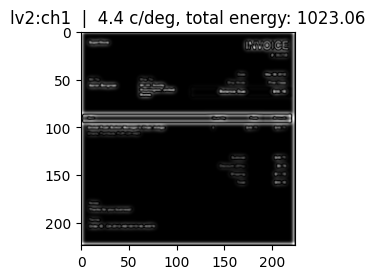

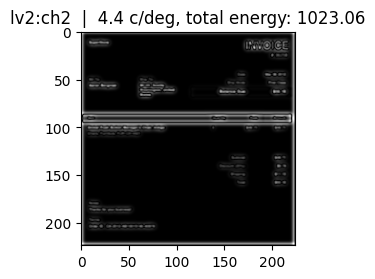

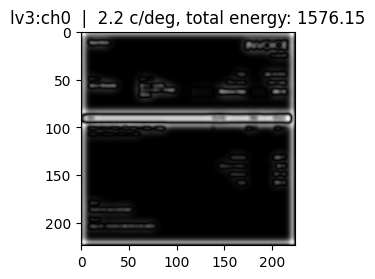

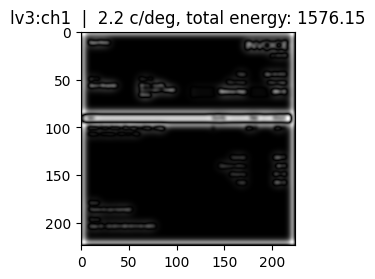

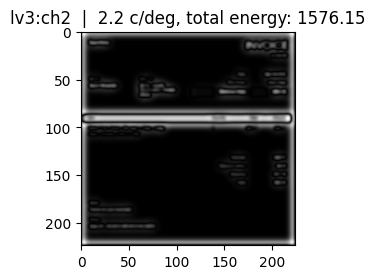

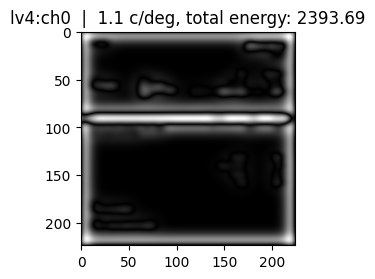

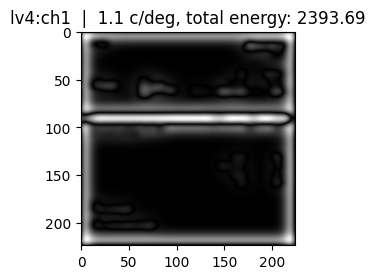

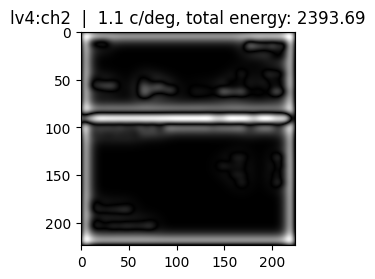

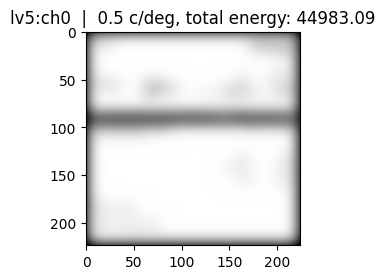

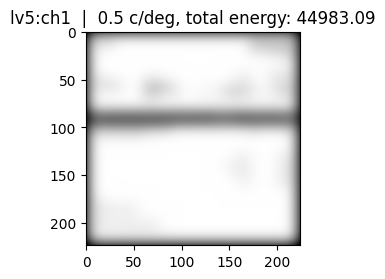

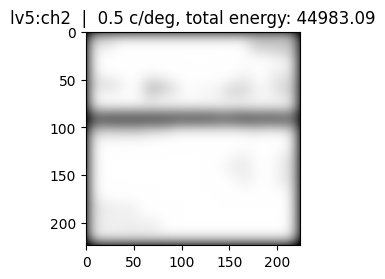

In [523]:
### check image edges:

#### contrast masking: allocate greater weight to specific frequency edges
#### (in specific perceputal channels)?

PYRAMID_SIZE = 6
BASE_SIGMA = 0.5
crop_pyramid = laplacian_pyramid(normalise(source_arr), levels=PYRAMID_SIZE, base_sigma=BASE_SIGMA)

# measure the total edge energy per band:
r_per_band = []
g_per_band = []
b_per_band = []
channelwise_energy_per_band = [r_per_band, g_per_band, b_per_band]

PPD = viz.get_ppd()
for band in range(PYRAMID_SIZE):
    if band == 0:
        
        cutoff = PPD / (2 * np.pi * BASE_SIGMA)
        nyquist = PPD / 2
        band_centre_freq = (cutoff + nyquist) / 2
    else:
        sigma_low = BASE_SIGMA * (2 ** (band - 1))
        sigma_high = BASE_SIGMA * (2 ** band)
        freq_low = PPD / (2 * np.pi * sigma_low)
        freq_high = PPD / (2 * np.pi * sigma_high)
        band_centre_freq = (freq_low + freq_high) / 2
    
    # band_centre_freq = center_freqs[band]
    # band_centre_S = np.where(x > band_centre_freq)[0][0]
    # band_centre_csf = np.asarray([(csf[band_centre_S]) for csf in [lum, rg, yb]])
    # sensitivities for each band:
    # S_lum, S_rg, S_yb = band_centre_csf
    
    
    for c in range(3):
        band_c_energy = np.abs(crop_pyramid[band][:,:,c])
        total_energy = (band_c_energy).sum()
        
        channelwise_energy_per_band[c].append(total_energy)
        # sensitivity = band_centre_csf[c]

        # show the edges at this frequency:
        rshow(band_c_energy, title=f'lv{band}:ch{c}  |  {band_centre_freq:.1f} c/deg, total energy: {total_energy:.2f}', vmin=0, vmax=255)
    
    

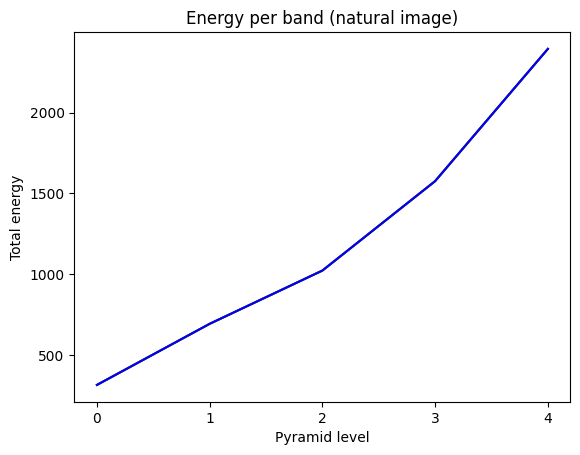

In [463]:
# show the energy per band:
plt.plot(range(PYRAMID_SIZE-1), r_per_band[:-1], c='red')
plt.plot(range(PYRAMID_SIZE-1), g_per_band[:-1], c='green')
plt.plot(range(PYRAMID_SIZE-1), b_per_band[:-1], c='blue')
plt.xticks(range(PYRAMID_SIZE-1))
plt.xlabel('Pyramid level')
plt.ylabel('Total energy')
plt.title('Energy per band (natural image)')
plt.show()

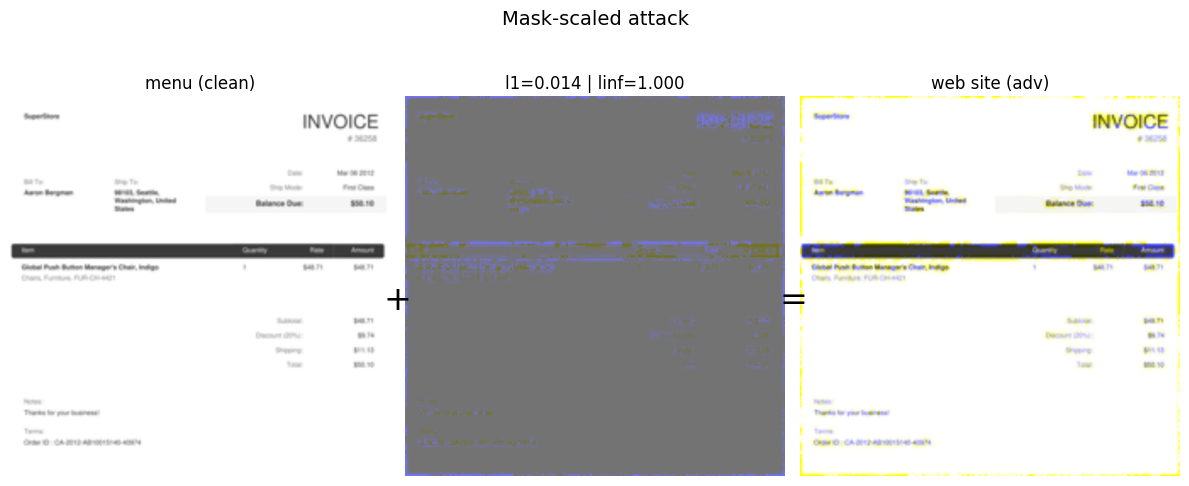

In [464]:
# edge-masked scaling of targeted attack:

def tshow(tensor, *args, **kwargs):
    hwc = tensor.squeeze().permute([1,2,0])
    hwc_arr = hwc.detach().cpu().numpy()
    rshow(hwc_arr, *args, **kwargs)

from torchvision.transforms.functional import to_tensor

orig_x, base_adv_x = next(iter(test_data_loader))[0], next(iter(attack_loader))[0]

edge_mask = to_tensor(normalise(np.abs(crop_pyramid[1].astype(np.float32))))

# blue channel only:
edge_mask[:2,:,:] = 0

base_delta = (base_adv_x - orig_x)
masked_delta = (edge_mask * base_delta) * 60

adv_x = torch.clamp(orig_x + masked_delta, 0, 1)
delta = (adv_x - orig_x)

delta_l1 = delta.abs().mean().item()
delta_linf = delta.abs().max().item()

darr = delta[0].permute([1,2,0]).detach().cpu().numpy() # as RGB numpy array wrt [0,1] float image
    
adv_logit = model(adv_x.to(device))
adv_idx = adv_logit.argmax(1)
adv_class = class_names[adv_idx.item()]
    
plot_adversarial_example(orig_x[0], adv_x[0],                
        orig_label=f"{out_class} (clean)",
        adv_label=f"{adv_class} (adv)",
        delta_label=f"l1={delta_l1:.3f} | linf={delta_linf:.3f}", 
        attack_name=f"Mask-scaled attack")

ASR (Patch-masked attack), Targeted):  1.0


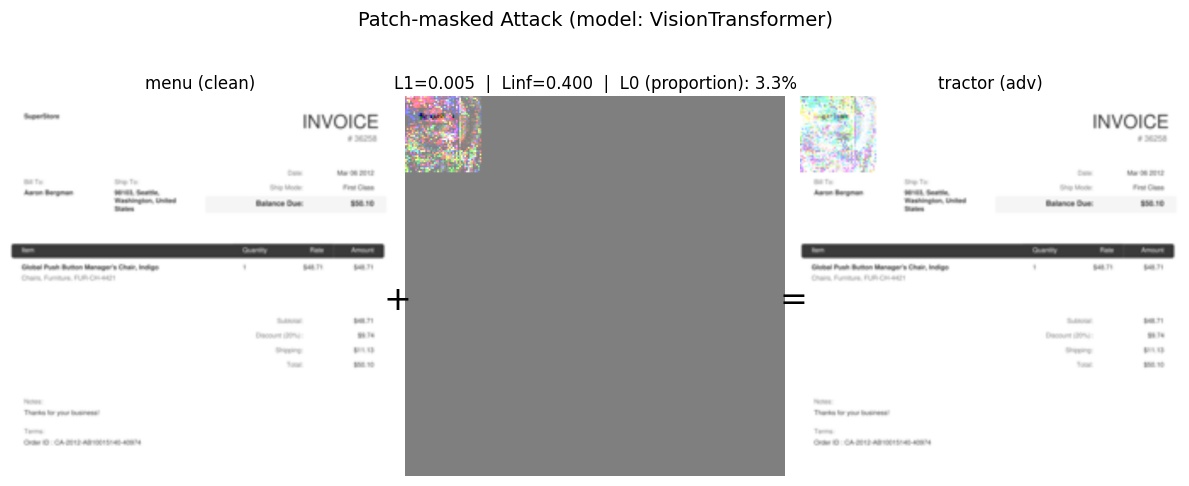

ASR (Edge-masked attack), Targeted):  1.0


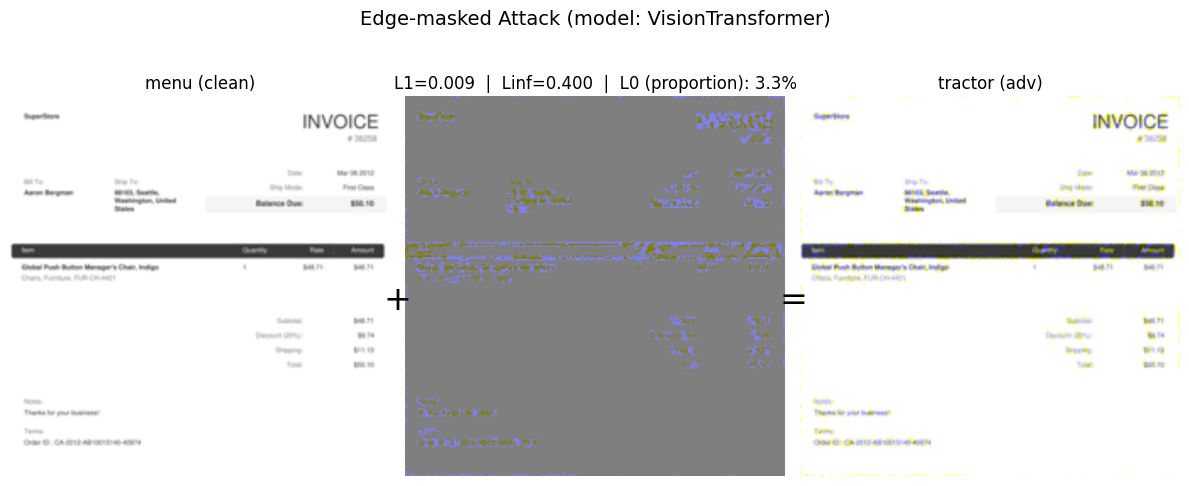

In [478]:
from secmlt.optimization.constraints import MaskConstraint
from secmlt.adv.evasion.pgd import PGD


# Create and run targeted masked attack

epsilon = 0.4 # originally 0.03

num_steps = 500
step_size = 2/255
perturbation_model = LpPerturbationModels.LINF
y_target = 866 # tractor





edge_mask = to_tensor(normalise(np.abs(crop_pyramid[0].astype(np.float32))))
# blue channel only:
edge_mask[:2,:,:] = 0
edge_mask = (edge_mask > 0.05).to(torch.float32)

### allocate approximately as many pixels to the patch mask as the edge mask:
patch_size = int(np.ceil( (edge_mask.sum()/3)**0.5))

patch_mask = torch.zeros_like(edge_mask)
patch_mask[:, :patch_size, :patch_size] = 1

masked_deltas = {}

for mask, mask_name in zip([patch_mask, edge_mask], ['Patch-masked', 'Edge-masked']):

    # tshow(mask)

    mask_attack_pgd = PGD(
        perturbation_model=perturbation_model,
        epsilon=epsilon,
        num_steps=num_steps,
        step_size=step_size,
        random_start=False,
        y_target=y_target,
        backend=Backends.NATIVE,
        )
    
    mask_attack_pgd.manipulation_function.perturbation_constraints.append(MaskConstraint(mask))

    
    
    mask_attack_t = mask_attack_pgd(model, test_data_loader)
    
    # Test attack success rate on adversarial examples
    n_robust_accuracy = AttackSuccessRate(y_target=y_target)(model, mask_attack_t)
    print(f"ASR ({mask_name} attack), Targeted): ", n_robust_accuracy.item())
    
    
    orig_x, adv_x = next(iter(test_data_loader))[0], next(iter(mask_attack_t))[0]
    
    delta = (adv_x - orig_x)

    masked_deltas[mask_name] = delta
    
    delta_l0 = (delta.abs() > 0).to(torch.float32).mean().item()
    delta_l1 = delta.abs().mean().item()
    delta_linf = delta.abs().max().item()
    
    darr = delta[0].permute([1,2,0]).detach().cpu().numpy() # as RGB numpy array wrt [0,1] float image
        
    adv_logit = model(adv_x.to(device))
    adv_idx = adv_logit.argmax(1)
    adv_class = class_names[adv_idx.item()]
        
    plot_adversarial_example(orig_x[0], adv_x[0],                
                orig_label=f"{out_class} (clean)",
                adv_label=f"{adv_class} (adv)",
                delta_label=f"L1={delta_l1:.3f}  |  Linf={delta_linf:.3f}  |  L0 (proportion): {delta_l0:.1%}", 
                attack_name=f"{mask_name} Attack (model: {str(model.model.__class__).split('.')[-1].split('\'')[0]})")

    # show adv image at full res:
    # tshow(adv_x[0])